In [20]:
import os
import sys
import glob
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import skimage as ski
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score

In [21]:
os.chdir(r"C:\Users\TOMLU\Desktop\Data3888\individual")

In [22]:
RANDOM_SEED = 3888

# adjust this based on what strategy has been used to produce train/test folds + what image size
# code assumes image_dir/folds/classes/[images here] structure
UNCENTERED_DIR = os.path.join("projectdata", "images", "uncentred_ternary_100_stratified4fold_1000per_seed3888")
# can change fold list 
FOLDS = ["Q1", "Q2", "Q3", "Q4"]
CLASSES = ["Tumor", "Non-Tumor", "Empty"]
DESIRED_IMAGE_SIZE = 100
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(RANDOM_SEED)
print(sys.version)

3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]


In [23]:
transform = transforms.Compose([
    transforms.Resize((DESIRED_IMAGE_SIZE, DESIRED_IMAGE_SIZE)),
    transforms.ToTensor()
])

In [24]:
def get_dataloaders_for_fold(test_fold):
    train_folds = [f for f in FOLDS if f != test_fold]

    train_datasets = []
    for fold in train_folds:
        path = os.path.join(UNCENTERED_DIR, fold) 
        dataset = datasets.ImageFolder(root=path, transform=transform)
        train_datasets.append(dataset)

    test_path = os.path.join(UNCENTERED_DIR, test_fold)
    test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

    train_loader = DataLoader(ConcatDataset(train_datasets), batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, test_loader

In [25]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 25 * 25, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [26]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [27]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return accuracy_score(all_labels, all_preds)


— Fold: Q1 —
Epoch 1/10 - Train Loss: 0.9191
Epoch 2/10 - Train Loss: 0.7077
Epoch 3/10 - Train Loss: 0.6729
Epoch 4/10 - Train Loss: 0.6485
Epoch 5/10 - Train Loss: 0.6399
Epoch 6/10 - Train Loss: 0.6046
Epoch 7/10 - Train Loss: 0.5739
Epoch 8/10 - Train Loss: 0.5635
Epoch 9/10 - Train Loss: 0.5356
Epoch 10/10 - Train Loss: 0.4944
Model saved to trained_model_fold_Q1.pth
Accuracy: 0.7704, F1-score: 0.7683
              precision    recall  f1-score   support

       Tumor       0.96      0.52      0.67       128
   Non-Tumor       0.71      0.83      0.76       500
       Empty       0.82      0.77      0.80       500

    accuracy                           0.77      1128
   macro avg       0.83      0.71      0.74      1128
weighted avg       0.79      0.77      0.77      1128



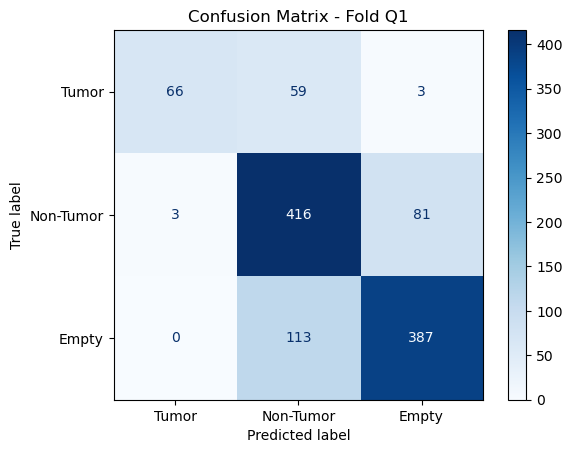


— Fold: Q2 —
Epoch 1/10 - Train Loss: 0.9636
Epoch 2/10 - Train Loss: 0.7358
Epoch 3/10 - Train Loss: 0.6867
Epoch 4/10 - Train Loss: 0.6463
Epoch 5/10 - Train Loss: 0.6315
Epoch 6/10 - Train Loss: 0.5956
Epoch 7/10 - Train Loss: 0.5814
Epoch 8/10 - Train Loss: 0.5456
Epoch 9/10 - Train Loss: 0.5361
Epoch 10/10 - Train Loss: 0.5298
Model saved to trained_model_fold_Q2.pth
Accuracy: 0.7128, F1-score: 0.7094
              precision    recall  f1-score   support

       Tumor       0.62      0.62      0.62       128
   Non-Tumor       0.73      0.62      0.67       500
       Empty       0.72      0.83      0.77       500

    accuracy                           0.71      1128
   macro avg       0.69      0.69      0.69      1128
weighted avg       0.71      0.71      0.71      1128



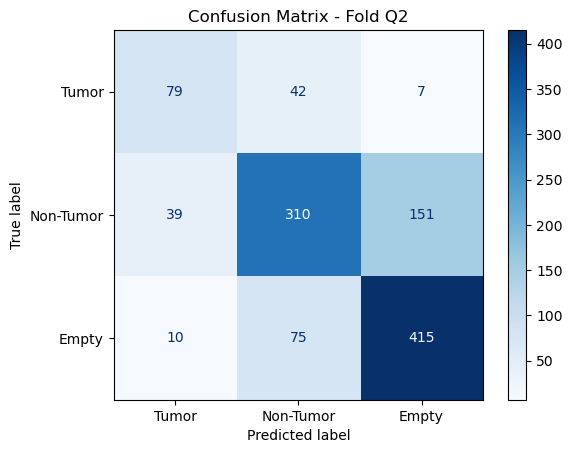


— Fold: Q3 —
Epoch 1/10 - Train Loss: 0.9472
Epoch 2/10 - Train Loss: 0.7247
Epoch 3/10 - Train Loss: 0.6842
Epoch 4/10 - Train Loss: 0.6640
Epoch 5/10 - Train Loss: 0.6222
Epoch 6/10 - Train Loss: 0.6163
Epoch 7/10 - Train Loss: 0.5769
Epoch 8/10 - Train Loss: 0.5790
Epoch 9/10 - Train Loss: 0.5335
Epoch 10/10 - Train Loss: 0.5232
Model saved to trained_model_fold_Q3.pth
Accuracy: 0.6800, F1-score: 0.6808
              precision    recall  f1-score   support

       Tumor       0.89      0.59      0.71       128
   Non-Tumor       0.63      0.71      0.67       500
       Empty       0.70      0.67      0.68       500

    accuracy                           0.68      1128
   macro avg       0.74      0.66      0.69      1128
weighted avg       0.69      0.68      0.68      1128



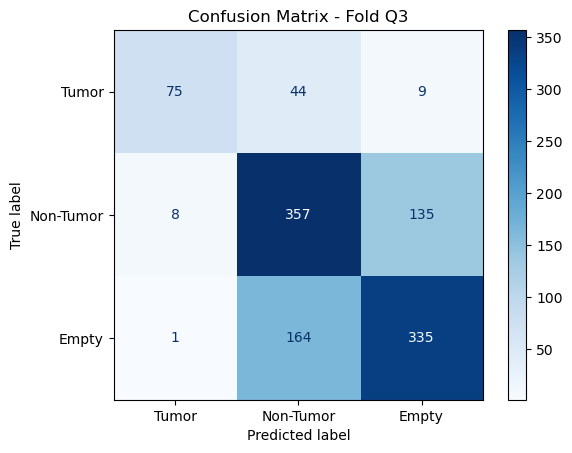


— Fold: Q4 —
Epoch 1/10 - Train Loss: 0.8526
Epoch 2/10 - Train Loss: 0.6757
Epoch 3/10 - Train Loss: 0.6423
Epoch 4/10 - Train Loss: 0.5908
Epoch 5/10 - Train Loss: 0.5656
Epoch 6/10 - Train Loss: 0.5419
Epoch 7/10 - Train Loss: 0.5100
Epoch 8/10 - Train Loss: 0.4729
Epoch 9/10 - Train Loss: 0.4477
Epoch 10/10 - Train Loss: 0.4067
Model saved to trained_model_fold_Q4.pth
Accuracy: 0.7349, F1-score: 0.7337
              precision    recall  f1-score   support

       Tumor       0.72      0.53      0.61       128
   Non-Tumor       0.69      0.78      0.73       500
       Empty       0.79      0.75      0.77       500

    accuracy                           0.73      1128
   macro avg       0.73      0.68      0.70      1128
weighted avg       0.74      0.73      0.73      1128



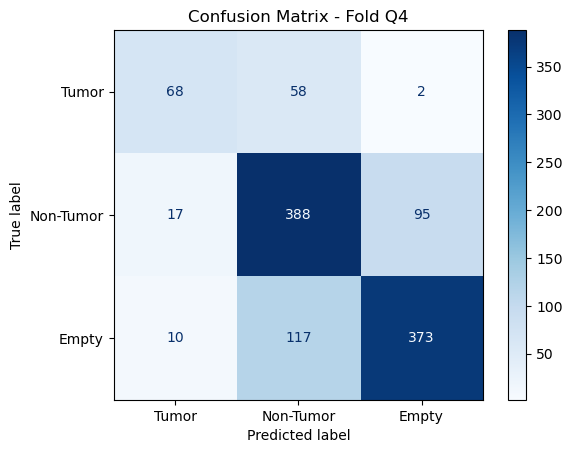

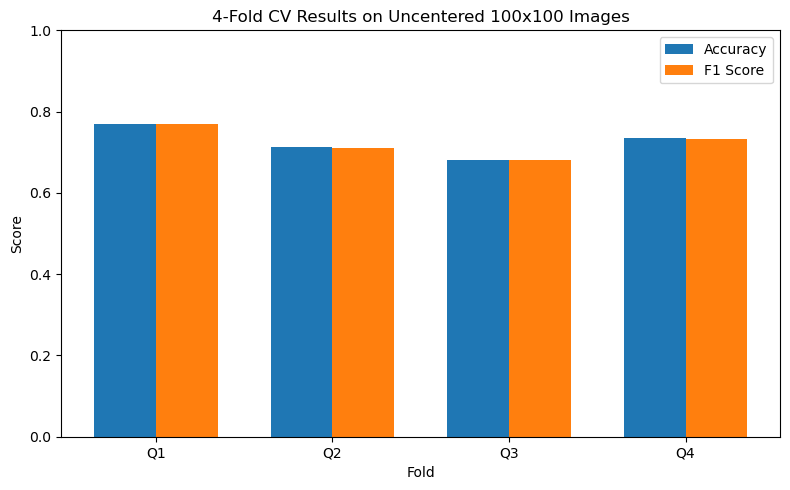

In [29]:
accuracies = []
f1_scores = []

for fold in FOLDS:
    print(f"\n— Fold: {fold} —")
    
   
    train_loader, test_loader = get_dataloaders_for_fold(fold)

    model = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        train_loss = train(model, train_loader, optimizer, criterion)
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}")

    torch.save(model.state_dict(), f"trained_model_fold_{fold}.pth")
    print(f"Model saved to trained_model_fold_{fold}.pth")

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    accuracies.append(acc)
    f1_scores.append(f1)

    print(f"Accuracy: {acc:.4f}, F1-score: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.show()


x = FOLDS
bar_width = 0.35
x_idx = np.arange(len(x))

plt.figure(figsize=(8, 5))
plt.bar(x_idx, accuracies, bar_width, label='Accuracy')
plt.bar(x_idx + bar_width, f1_scores, bar_width, label='F1 Score')
plt.xticks(x_idx + bar_width / 2, x)
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('4-Fold CV Results on Uncentered 100x100 Images')
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()